# <font color="#2E86C1"><b>AICE Associate 대비 실전 모의고사 (6회 심화)</b></font>
---


##  <font color="#117A65"><b>통신사 해지 고객 예측 (telecom Prediction)</b></font>

### <font color="#5D6D7E"><b>목적</b></font>  
고객 데이터를 기반으로 해지 여부를 예측하고, 다양한 전처리 기법과 모델 비교 분석을 통해 최적의 모델을 도출합니다.

### <font color="#5D6D7E"><b>데이터 설명</b></font>
<b>파일 이름: `telecom.csv`</b>

| <b>컬럼명</b> | <b>설명</b> |
|---|---|
| `고객ID` | 고객 식별 번호 |
| `연령` | 고객의 나이 |
| `성별` | 남성 / 여성 |
| `지역` | 거주 지역 |
| `가입기간` | 서비스 가입 월수 |
| `월요금` | 매월 지불하는 요금 |
| `총요금` | 지금까지 지불한 총 요금 |
| `상담횟수` | 고객센터 상담 횟수 |
| `데이터사용량` | 월평균 데이터 사용량 |
| `계약유형` | 약정 유무 (약정없음, 1년약정, 2년약정) |
| `해지여부` | <mark><b>해지 여부 (1: 해지, 0: 유지)</b></mark> |

---

## [문제 1] 라이브러리 임포트

🎯 목표: 분석에 필요한 핵심 라이브러리(pandas, numpy, sns, plt)를 임포트하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## [문제 2] 데이터 불러오기

🎯 목표: `telecom.csv` 파일을 읽어 `telecom_df`라는 이름의 데이터프레임에 저장하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [2]:
telecom_df = pd.read_csv('datasets/telecom.csv')

#### 시각화의 한글화를 위해 다음의 코드를 실행하세요

In [3]:
from matplotlib import font_manager, rc
import platform

system = platform.system()

if system == 'Windows':
    rc('font', family='Malgun Gothic')

elif system == 'Darwin':  # macOS
    rc('font', family='AppleGothic')

else:  # Linux 등
    rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

## [문제 3] 데이터 시각화 및 해석

🎯 목표  
- 월요금에 대한 해지여부에 따른 차이를 설명하세요.

📑 조건
- `sns.histplot`을 사용하여 월요금에 대한 histplot을 그리세요.
- `hue`를 사용하여 해지여부에 따른 차이를 시각화하세요.


📑 문제  다음 히스토그램은 해지 여부(0, 1)에 따른 월 보험료 분포를 나타낸 것이다.
그래프를 보고 판단한 내용 중 가장 타당한 것은 무엇인가?

1️⃣ 해지 여부 0 집단은 주로 낮은 월요금 구간에서 값이 많이 나타난다.

2️⃣ 해지 여부 1 집단은 주로 낮은 월요금 구간에서 값이 많이 나타난다.

3️⃣ 두 집단은 낮은 월요금 구간에서 거의 같은 수준으로 나타난다.

4️⃣ 해지 여부 0 집단은 높은 월요금 구간에서만 나타난다.

정답을 `정답_3` 변수에 저장하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

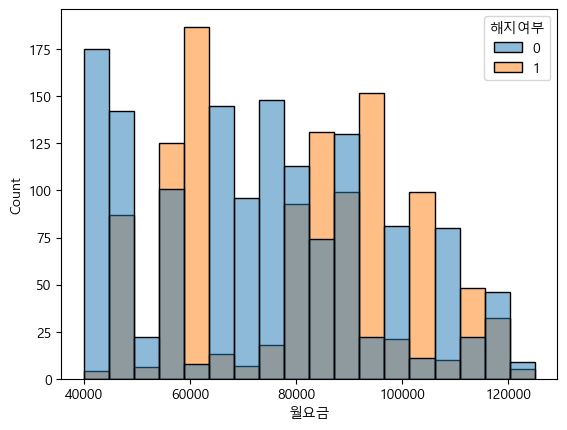

In [4]:
sns.histplot(data=telecom_df, x='월요금', hue='해지여부')
plt.show()
정답_3 = 1

## [문제 4] 결측치 처리1

🎯 목표
- `연령` 컬럼의 결측치를 `평균값`으로, `지역` 컬럼의 결측치를 `최빈값`으로 채우고자 합니다.  
📑 조건
- 다음의 빈칸에 알맞는 코드를 `문제4_1`, `문제4_2` 각각 변수에 입력하세요.  
- 정답은 `''` 안에 작성해 주시고, 완성된 코드를 실행해주세요.  
 -- 예) 문제4_1 = 'sum()'

telecom_df['연령'].fillna(telecom_df['연령'].`<문제4-1>`, inplace=True)  
telecom_df['지역'].fillna(telecom_df['지역'].`<문제4-2>`, inplace=True)


In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [6]:
문제4_1 = 'mean()'
문제4_2 = 'mode()[0]'

telecom_df['연령'].fillna(telecom_df['연령'].mean(), inplace=True)  
telecom_df['지역'].fillna(telecom_df['지역'].mode()[0], inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_29268\675422334.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  telecom_df['연령'].fillna(telecom_df['연령'].mean(), inplace=True)


## [문제 5] 결측치 처리2

🎯 목표
- `총요금` 컬럼의 결측치를 논리적 근거(`월요금 * 가입기간`)를 바탕으로 채우세요.
- 데이터셋에 존재하는 중복된 행을 제거하세요.

📑 조건
- 결측치가 있는 곳에만 `월요금 * 가입기간` 결과값이 들어가도록 하세요.
- `고객ID` 컬럼을 기준으로 중복된 행을 제거하도록 하세요.


In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [7]:
telecom_df['총요금'] = telecom_df['총요금'].fillna(telecom_df['월요금'] * telecom_df['가입기간'])
telecom_df.drop_duplicates(subset='고객ID', inplace=True)

## [문제 6] 데이터 정제

🎯 목표: 불필요한 데이터를 제거하여 데이터의 품질을 높이세요.

📑 조건 및 세부 문항
- 4-1: `고객ID` 컬럼을 삭제하세요.
- 4-2: `월요금`이 110,000원 이상이면서 `상담횟수`가 0번인 고객 데이터를 이상치로 간주하여 삭제하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [8]:
# 6-1. 컬럼 제거
telecom_df.drop(columns=['고객ID'], inplace=True)

# 6-2. 조건부 행 제거
telecom_df.drop(telecom_df[(telecom_df['월요금'] >= 110000) & (telecom_df['상담횟수'] == 0)].index, inplace=True)

## [문제 7] 범주형 변수 인코딩

🎯 목표: 범주형 변수들을 인코딩하세요.

📑 조건  
- `성별` 컬럼은 `map`함수를 사용하여 `여성`을 0, `남성`을 1로 인코딩하세요.
- `지역`, `계약유형`을 `get_dummies`를 사용하여 원-핫 인코딩하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [9]:
telecom_df['성별'] = telecom_df['성별'].map({'여성': 0, '남성': 1})
telecom_df = pd.get_dummies(telecom_df, columns=['지역', '계약유형'])

## [문제 8] 데이터 분리 및 분할

🎯 목표: 피처/타겟 분리는 X, y변수에 처리하고, train_test_split을 사용하여 학습/테스트 데이터 분할(8:2)을 수행하세요.

📑 조건
- X: `해지여부`를 제외한 모든 컬럼
- y: `해지여부`
- `random_state=42` 
- `stratify`는 `y`를 기준으로 처리

In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [10]:
from sklearn.model_selection import train_test_split

X = telecom_df.drop('해지여부', axis=1)
y = telecom_df['해지여부']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## [문제 9] 수치형 데이터 스케일링

🎯 목표: 학습/테스트 데이터에서 수치형 컬럼만 선택하여 스케일링을 적용하세요.

📑 조건
- `StandardScaler`를 사용할 것
- 해당 변수는 `연령`, `가입기간`, `월요금`, `총요금`만 스케일링 할 것
- 훈련 데이터는 `fit_transform` 적용하여 `X_train_scaled` 변수에 저장
- 테스트 데이터는 `transform` 적용하여 `X_test_scaled` 변수에 저장

In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = X_train[['연령', '가입기간', '월요금', '총요금']]
X_test_num = X_test[['연령', '가입기간', '월요금', '총요금']]

X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

In [12]:
# 수치형 변수 스케일링한 것과 범주형 변수 인코딩한 것을 합쳐야 하므로 다음 코드를 실행하여 주세요.
cat_cols = [
    '지역_경기','지역_기타','지역_대구','지역_부산','지역_서울',
    '계약유형_1년약정','계약유형_2년약정','계약유형_약정없음',
    '성별'
]

X_train_scaled = pd.DataFrame(X_train_scaled,
                              index=X_train.index,
                              columns=X_train_num.columns)

X_test_scaled = pd.DataFrame(X_test_scaled,
                             index=X_test.index,
                             columns=X_test_num.columns)

X_train_scaled = pd.concat([X_train_scaled, X_train[cat_cols]], axis=1)
X_test_scaled  = pd.concat([X_test_scaled,  X_test[cat_cols]],  axis=1)


## [문제 10] 머신러닝 모델 구축

🎯 목표: 로지스틱 회귀 모델과 랜덤 포레스트 모델을 생성하고 학습시키세요.

📑 조건
- 로지스틱 회귀 모델은 lr_model 변수에 저장
- 파라미터는 random_state=42, max_iter=1000, C=0.1
- 랜덤 포레스트 모델은 rf_model 변수에 저장
- 파라미터는 random_state=42, n_estimators=50, max_depth=5, min_samples_split=5

- 모델은 스케일링된 데이터로 학습

In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [ ]:
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier

model_lr = LogisticRegression(random_state=42, max_iter=1000, C=0.1)
model_lr.fit(X_train_scaled, y_train)

model_rf = RandomForestClassifier(random_state=42, n_estimators=50, max_depth=5, min_samples_split=5)
model_rf.fit(X_train_scaled, y_train)

## [문제 11] 머신러닝 모델 성능 비교 

🎯 목표: 로지스틱 회귀와 랜덤포레스트 모델의 성능을 비교하고 최적의 모델을 선택하세요.

📑 세부 조건
1. 로지스틱 회귀(`model_lr`)와 랜덤포레스트(`model_rf`)의 예측값을 구하세요.
2. 두 모델의 Accuracy와 F1-score를 출력하세요.
 - 로지스틱 회귀의 Accuracy는 `acc_lr`변수에 저장하세요.
 - 로지스틱 회귀의 F1-score는 `f1_lr`변수에 저장하세요.
 - 랜덤포레스트의 Accuracy는 `acc_rf`변수에 저장하세요.
 - 랜덤포레스트의 F1-score는 `f1_rf`변수에 저장하세요.
3. 두 모델 중 F1-score가 더 높은 모델의 이름을 `정답_11`변수에 저장하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# 랜덤포레스트 학습
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)

# 예측
pred_lr = model_lr.predict(X_test_scaled)
pred_rf = model_rf.predict(X_test_scaled)

# 평가
f1_lr = f1_score(y_test, pred_lr)
f1_rf = f1_score(y_test, pred_rf)

print(f"LR - Acc: {accuracy_score(y_test, pred_lr):.4f}, F1: {f1_lr:.4f}")
print(f"RF - Acc: {accuracy_score(y_test, pred_rf):.4f}, F1: {f1_rf:.4f}")

정답_11 = 'RandomForest'

## 딥러닝 전처리 및 환경 설정
🖋 **상황 설명** 
딥러닝 모델 학습을 위해 필요한 라이브러리를 임포트하고 동일한 결과를 얻기 위한 시드 설정을 수행합니다.  
아래 코드를 먼저 실행하세요.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.random.set_seed(10)

## [문제 12] 딥러닝 모델 설계 및 컴파일

🖋 **상황 설명** 
모델의 성능 향상과 학습 안정화를 위해 3개의 은닉층을 가진 신경망 구조를 설계하고 컴파일합니다.  
배치 정규화(BatchNormalization)와 selu 활성화 함수를 사용하고, 마지막 은닉층에는 드롭아웃(Dropout)을 적용하여 과적합을 방지하세요.

🎯 **목표**

* Sequential 모델을 사용하여 아래 구조의 신경망을 설계하세요.

* **은닉층 구조**:
  * 1번 은닉층: `Dense(64, activation='selu')` → `BatchNormalization()`
  * 2번 은닉층: `Dense(32, activation='selu')` → `BatchNormalization()`
  * 3번 은닉층: `Dense(16, activation='selu')` → `Dropout(0.2)`

* **출력층**: `Dense(1, activation='sigmoid')`

* **컴파일 설정**:
  * optimizer: 'adam'
  * loss: 'binary_crossentropy'
  * metrics: ['accuracy']

📑 **조건**

* 모델 객체는 `model` 변수에 저장하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [ ]:
model = Sequential([
    Dense(64, activation='selu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dense(32, activation='selu'),
    BatchNormalization(),
    Dense(16, activation='selu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

## [문제 13] 딥러닝 모델 학습 (fit)

🖋 **상황 설명** 
모델의 학습 과정을 모니터링하기 위한 콜백 함수를 설정하고, 실제 데이터를 사용하여 모델을 학습시킵니다.

🎯 **목표**

* **콜백 설정**:
  * `EarlyStopping`: `val_loss` 기준, 5번 동안 개선되지 않으면 학습 종료.
  * `ModelCheckpoint`: 최적 가중치를 `best_model.keras`로 저장 (restore_best_weights=True).

* **모델 학습**:
  * 설정: `epochs=50`, `batch_size=128`, `validation_split=0.2`, `test_data=(X_test_scaled, y_test)`

📑 **조건**

* 생성한 콜백 리스트를 `callbacks` 변수에 담아 학습 시 적용하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mc = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
callbacks = [es, mc]

history = model.fit(X_train_scaled, y_train, 
                    epochs=50, 
                    batch_size=128, 
                    validation_split=0.2, 
                    callbacks=callbacks)

## [문제 14] 데이터 예측 및 결과 저장

🖋 **상황 설명** 
학습이 완료된 최적의 모델을 사용하여 테스트 데이터의 클래스를 예측합니다.

🎯 **목표**

* 주어진 데이터에 대한 예측을 수행하세요.  
* 주어진 데이터는 위에서 처리된 `scaler`의 `transform`을 이용하여 처리된 데이터입니다.(조작 금지)

📑 **조건**
* `pred_data`를 `model`의 `predict`를 이용하여 예측값을 구하고 `pred_proba`에 저장하세요.
* 예측된 확률값이 0.5보다 크면 1, 작으면 0으로 `정답_14` 변수에 저장하세요.

In [ ]:
# 제공 데이터
pred_data = np.array([0.279998, -0.416104, -0.378967, -0.411085, False, False, True, False, False, True, False, False, 0]).reshape(1, -1)

In [ ]:
# 여기에 답안코드를 작성하세요.


##### **정답코드**

In [ ]:
pred_proba = model.predict(pred_data)
pred_proba
정답_14 = 0